## Skin Cancer Detection




This notebook explores the task of skin cancer detection using deep learning. We will train and evaluate a Tranfers learning models to classify skin lesions as either benign or malignant.

### Dataset
We will be using the skinskin_df_eda dataset, that is generated by the [Skin Cancer Detection - EDA.ipynb](https://https://colab.research.google.com/drive/165nG1oECZBc8RKacPjCbyKVZblZ1yM2-?usp=sharing) colab.

### Approach
The notebook follows these steps:
1.  **Data Loading and Preprocessing**: Loading the dataset, and preparing image data generators for training and validation.
2.  **Model Development**: We will develop and compare three types of models:
    *   **Baseline Model**: A MobileNetV2-based model with a simple classification head, trained without advanced techniques.
    *   **Advanced Model**: An improved MobileNetV2-based model with a more sophisticated classification head, including `BatchNormalization` and `Dropout`, and fine-tuned with a lower learning rate and callbacks (`ReduceLROnPlateau`, `EarlyStopping`, `ModelCheckpoint`).
    *   **Imbalanced Model**: Similar to the Advanced Model, but trained with `class_weights` to address the inherent class imbalance in the dataset, aiming to improve the detection of the minority (malignant) class.
3.  **Model Evaluation**: Each model will be evaluated using standard metrics such as accuracy, precision, recall, and loss on a held-out test set. We will specifically focus on recall for malignant cases, as missing a malignant diagnosis can have severe consequences.
4.  **Confusion Matrix Analysis**: Detailed analysis of confusion matrices for each model to understand their performance in terms of True Positives, False Positives, True Negatives, and False Negatives.
5.  **Conclusion**: A comparative summary of all models, highlighting the best-performing model based on the specific requirements of skin cancer detection (minimizing false negatives).

## Libraries Import

In [44]:
import cv2
from collections import defaultdict
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from glob import glob
import seaborn as sns
from PIL import Image
import hashlib

np.random.seed(123)
import operator

import keras
from keras.utils import to_categorical # used for converting labels to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

import pandas as pd
import tensorflow as tf

from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.utils import class_weight

from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(['#da6b87',
                              '#7d233c', #rosa oscuro
                              '#cfbdb0', #beige oscuro
                              '#f1e6de'
                              ])

## Load Dataset

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# Download latest version, this is needed to be able to download images
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [47]:
drive_path = '/content/drive/MyDrive/skin_df_eda.xlsx'
skin_df = pd.read_excel(drive_path)

print("skin_df loaded successfully.\n")
display(skin_df.head())

# Ensure `is_malignant` is string type for ImageDataGenerator
skin_df['is_malignant_str'] = skin_df['is_malignant'].astype(str)

skin_df loaded successfully.



,lesion_id,image_id,dx_type,age,sex,localization,path,cell_type,cell_type_idx,is_malignant
0,HAM_0000118,ISIC_0027419,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2,False
1,HAM_0000118,ISIC_0025030,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2,False
2,HAM_0002730,ISIC_0026769,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2,False
3,HAM_0002730,ISIC_0025661,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2,False
4,HAM_0001466,ISIC_0031633,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2,False


In [48]:
pd.set_option('display.max_colwidth', None)
skin_df["path"].head()

,path
0,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
1,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg
2,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg
3,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025661.jpg
4,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0031633.jpg


## Prepare Train and Validation Dataset

In [43]:
IMG_WIDTH = 100
IMG_HEIGHT = 75
BATCH_SIZE = 32
RANDOM_STATE = 1234
EPOCHS = 15

In [49]:
# Split data into training, validation, and test sets
# First split for training and temporary test/validation set
train_df, temp_df = train_test_split(skin_df, test_size=0.3, random_state=RANDOM_STATE, stratify=skin_df['is_malignant_str'])

# Second split for validation and test sets
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_df['is_malignant_str'])

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 6977
Validation set size: 1495
Test set size: 1496


# Initialize and Prepare Models




Our plan is to train and test different combinations of the same baseline model. Start without hyperparameter or any advance techniques, then start to add those.

Two ImageDataGenerator instances were created, one for training with augmentation and one for validation/testing with only rescaling. Then train, validation, and test data generators were created using these instances and the respective dataframes.



In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='is_malignant_str',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='is_malignant_str',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='is_malignant_str',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Data generators created successfully.")

Found 6976 validated image filenames belonging to 2 classes.
Found 1495 validated image filenames belonging to 2 classes.
Found 1495 validated image filenames belonging to 2 classes.
Data generators created successfully.


## Baseline Model initialization

We decided to init the training with MobileNetV2 as base model. For that we initialized it with a custom classification layer. The first approach is withouth any hyperparameter tunning or any advance NN strategy.


We initialized the The MobileNetV2 base model by specifying the input shape, excluding the top layers, and loading pre-trained ImageNet weights. Then, we freezed the base model's layers to prevent them from being updated during training.



### MobileNetV2 vs. ResNet Comparison

Both MobileNetV2 and ResNet are powerful convolutional neural network architectures, but they were designed with different priorities in mind:

**ResNet (Residual Networks):**

*   **Key Innovation:** Introduced "residual connections" (skip connections) that allow the network to train much deeper layers by mitigating the vanishing gradient problem. This enables the construction of very deep networks that can learn highly complex features.
*   **Strengths:** Known for achieving state-of-the-art accuracy on many image recognition benchmarks due to its ability to go very deep. It's highly effective for tasks where maximizing accuracy is the absolute top priority and computational resources are abundant.
*   **Weaknesses:** Generally more computationally expensive and has a larger number of parameters compared to MobileNetV2, making it less suitable for deployment on resource-constrained devices or in real-time applications.
*   **Typical Use Cases:** High-accuracy tasks, research, cloud-based deployments, large-scale image classification where computational cost is secondary to performance.

**MobileNetV2:**
*   **Key Innovation:** Uses depthwise separable convolutions and inverted residuals with linear bottlenecks to drastically reduce computation and parameters.
*   **Strengths:** Highly efficient in terms of computational cost and memory footprint. It's designed to run effectively on mobile devices and embedded systems, making it ideal for on-device AI applications. It offers a good balance between accuracy and efficiency.
*   **Weaknesses:** While very accurate for its size, it might not reach the absolute highest accuracy levels achievable by much larger, deeper models like very large ResNets, especially on extremely complex or fine-grained classification tasks.
*   **Typical Use Cases:** Mobile applications, edge computing, real-time inference, applications where efficiency, speed, and small model size are critical.

For our skin cancer detection task, where quick and efficient inference (potentially on a device) might be desirable, and getting a robust model without excessive computational cost, MobileNetV2 is a very strong candidate.

In [ ]:
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
                          include_top=False,
                          weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

print("MobileNetV2 base model initialized and layers frozen successfully.")

/tmp/ipython-input-2383774796.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),


MobileNetV2 base model initialized and layers frozen successfully.


**Train Model**

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# Calculate steps per epoch and validation steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

print("Model built and compiled successfully. Starting training...")

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps
)

print("Model training completed.")

Model built and compiled successfully. Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 168s 745ms/step - accuracy: 0.7798 - loss: 0.5219 - precision_1: 0.3544 - recall_1: 0.1352 - val_accuracy: 0.7996 - val_loss: 0.4275 - val_precision_1: 0.4774 - val_recall_1: 0.3322
Epoch 2/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 133s 611ms/step - accuracy: 0.8166 - loss: 0.4216 - precision_1: 0.5433 - recall_1: 0.2679 - val_accuracy: 0.8037 - val_loss: 0.4218 - val_precision_1: 0.4937 - val_recall_1: 0.4091
Epoch 3/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 123s 566ms/step - accuracy: 0.8097 - loss: 0.4205 - precision_1: 0.5434 - recall_1: 0.2841 - val_accuracy: 0.8152 - val_loss: 0.3964 - val_precision_1: 0.5515 - val_recall_1: 0.2622
Epoch 4/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 123s 561ms/step - accuracy: 0.8109 - loss: 0.4078 - precision_1: 0.5449 - recall_1: 0.2621 - val_accuracy: 0.8159 - val_loss: 0.4035 - val_precision_1: 0.5843 - val_recall_1: 0.1818
Epoch 5/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 143s 655ms/step - accuracy: 0.8251 - loss: 0.4020 - precision_1: 0.6004 

### Advanced Model




We initialized a new MobileNetV2 base model, unfreezing a portion of its layers for fine-tuning. Added a more sophisticated custom classification head, potentially including additional layers like Dropout or BatchNormalization for regularization, to build the advanced model.


In [ ]:
base_model_advanced = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
                                  include_top=False,
                                  weights='imagenet')

# Set the base model to be trainable
base_model_advanced.trainable = True

# Freeze the initial layers (e.g., first 100 layers) for fine-tuning
for layer in base_model_advanced.layers[:100]:
    layer.trainable = False

# Add a custom classification head
x = base_model_advanced.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Added a Dense layer with relu activation
x = BatchNormalization()(x) # Added BatchNormalization
x = Dropout(0.3)(x) # Added Dropout
prediction = Dense(1, activation='sigmoid')(x)

advanced_model = Model(inputs=base_model_advanced.input, outputs=prediction)

print("Advanced MobileNetV2 model initialized with custom head and partial freezing.")

/tmp/ipython-input-1549713221.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_advanced = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),


Advanced MobileNetV2 model initialized with custom head and partial freezing.


The previous code block successfully initialized the advanced model. The `UserWarning` regarding the input shape is informational, as `IMG_WIDTH` and `IMG_HEIGHT` are intentionally set to non-standard dimensions.


In [ ]:
advanced_model.compile(optimizer=Adam(learning_rate=0.0001), # Lower learning rate for fine-tuning
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("Advanced model compiled successfully.")

Advanced model compiled successfully.


**Compile Advanced Model with Callbacks**



We configured a `ReduceLROnPlateau` for adaptive learning rate adjustment, `EarlyStopping` to monitor validation loss and prevent overfitting, and `ModelCheckpoint` to save the best model weights for the advanced model.

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.1,
                              patience=3,
                              min_lr=0.000001,
                              verbose=1)

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               verbose=1)

model_checkpoint = ModelCheckpoint(filepath='best_advanced_model.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   verbose=1)

callbacks = [reduce_lr, early_stopping, model_checkpoint]

print("Callbacks initialized successfully.")

Callbacks initialized successfully.


**Train Advanced Model**

In [ ]:
print("Starting training for advanced model...")

# Calculate steps per epoch and validation steps
steps_per_epoch_advanced = train_generator.samples // BATCH_SIZE
validation_steps_advanced = val_generator.samples // BATCH_SIZE

# Train the advanced model
history_advanced = advanced_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_advanced,
    epochs=EPOCHS, # We work with the same number of EPOCH regardless the early stop, to avoid more time in training
    validation_data=val_generator,
    validation_steps=validation_steps_advanced,
    callbacks=callbacks
)

print("Advanced model training completed.")

Starting training for advanced model...
Epoch 1/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.5739 - loss: 0.8444 - precision_2: 0.2623 - recall_2: 0.6322
Epoch 1: val_loss improved from inf to 0.48897, saving model to best_advanced_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 205s 833ms/step - accuracy: 0.5741 - loss: 0.8441 - precision_2: 0.2624 - recall_2: 0.6323 - val_accuracy: 0.8077 - val_loss: 0.4890 - val_precision_2: 0.5101 - val_recall_2: 0.2657 - learning_rate: 1.0000e-04
Epoch 2/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.7047 - loss: 0.6362 - precision_2: 0.3689 - recall_2: 0.6849
Epoch 2: val_loss did not improve from 0.48897
218/218 ━━━━━━━━━━━━━━━━━━━━ 163s 748ms/step - accuracy: 0.7047 - loss: 0.6361 - precision_2: 0.3689 - recall_2: 0.6848 - val_accuracy: 0.8111 - val_loss: 0.4958 - val_precision_2: 0.5645 - val_recall_2: 0.1224 - learning_rate: 1.0000e-04
Epoch 3/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.7566 - loss: 0.5597

## Evaluate Baseline Model

In [ ]:
print("Evaluating baseline model on test data...")
eval_results_baseline = model.evaluate(test_generator)

# Extract metrics from the evaluation results
loss_baseline = eval_results_baseline[0]
accuracy_baseline = eval_results_baseline[1]
precision_baseline = eval_results_baseline[2]
recall_baseline = eval_results_baseline[3]

print(f"Baseline Test Loss: {loss_baseline:.4f}")
print(f"Baseline Test Accuracy: {accuracy_baseline:.4f}")
print(f"Baseline Test Precision: {precision_baseline:.4f}")
print(f"Baseline Test Recall: {recall_baseline:.4f}")
print("Baseline model evaluation completed.")

Evaluating baseline model on test data...
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 508ms/step - accuracy: 0.8252 - loss: 0.3935 - precision_1: 0.5823 - recall_1: 0.4419
Baseline Test Loss: 0.3958
Baseline Test Accuracy: 0.8207
Baseline Test Precision: 0.5556
Baseline Test Recall: 0.4266
Baseline model evaluation completed.


Evaluate the advanced model on the test data to obtain its performance metrics, similar to what was done for the baseline model.



In [ ]:
print("Evaluating advanced model on test data...")
eval_results_advanced = advanced_model.evaluate(test_generator)

# Extract metrics from the evaluation results
loss_advanced = eval_results_advanced[0]
accuracy_advanced = eval_results_advanced[1]
precision_advanced = eval_results_advanced[2]
recall_advanced = eval_results_advanced[3]

print(f"Advanced Test Loss: {loss_advanced:.4f}")
print(f"Advanced Test Accuracy: {accuracy_advanced:.4f}")
print(f"Advanced Test Precision: {precision_advanced:.4f}")
print(f"Advanced Test Recall: {recall_advanced:.4f}")
print("Advanced model evaluation completed.")

Evaluating advanced model on test data...
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 379ms/step - accuracy: 0.8608 - loss: 0.3302 - precision_2: 0.7127 - recall_2: 0.5025
Advanced Test Loss: 0.3348
Advanced Test Accuracy: 0.8548
Advanced Test Precision: 0.6959
Advanced Test Recall: 0.4608
Advanced model evaluation completed.


Visualize the training histories of both the baseline and advanced models to observe their performance trends over epochs.



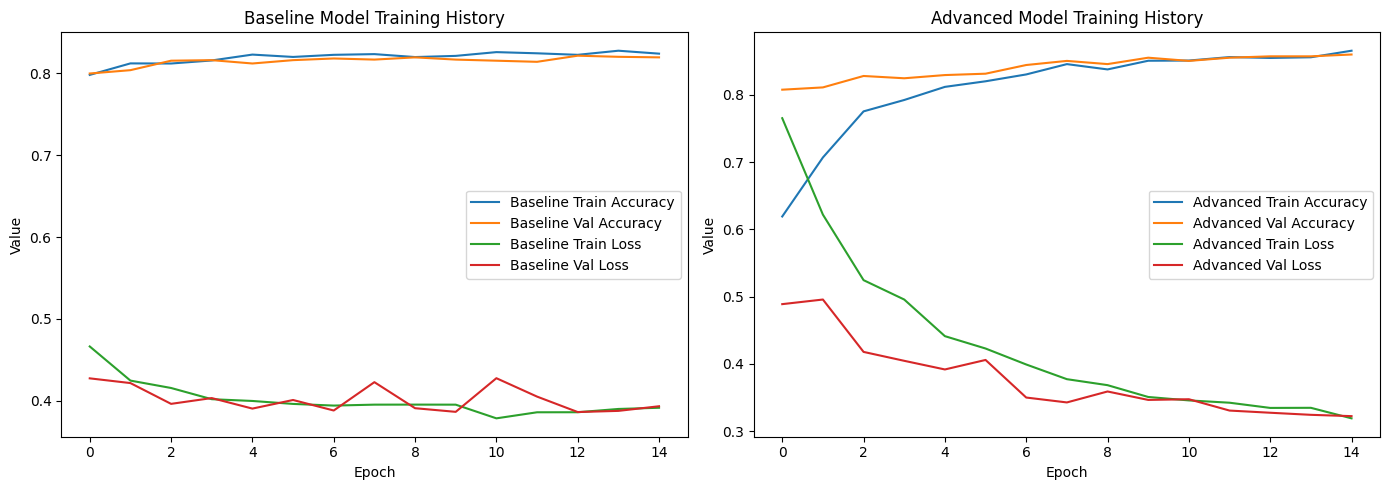

Training histories for both models plotted successfully.


In [ ]:
# Plot training history for baseline model
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(history.history['loss'], label='Baseline Train Loss')
plt.plot(history.history['val_loss'], label='Baseline Val Loss')
plt.title('Baseline Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

# Plot training history for advanced model
plt.subplot(1, 2, 2)
plt.plot(history_advanced.history['accuracy'], label='Advanced Train Accuracy')
plt.plot(history_advanced.history['val_accuracy'], label='Advanced Val Accuracy')
plt.plot(history_advanced.history['loss'], label='Advanced Train Loss')
plt.plot(history_advanced.history['val_loss'], label='Advanced Val Loss')
plt.title('Advanced Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

print("Training histories for both models plotted successfully.")

Now that both models have been evaluated and their training histories visualized, the next logical step is to compare their final test metrics to quantify the performance differences.



In [ ]:
print("\n--- Model Performance Comparison ---")
print("Baseline Model:")
print(f"  Loss: {loss_baseline:.4f}")
print(f"  Accuracy: {accuracy_baseline:.4f}")
print(f"  Precision: {precision_baseline:.4f}")
print(f"  Recall: {recall_baseline:.4f}")

print("\nAdvanced Model:")
print(f"  Loss: {loss_advanced:.4f}")
print(f"  Accuracy: {accuracy_advanced:.4f}")
print(f"  Precision: {precision_advanced:.4f}")
print(f"  Recall: {recall_advanced:.4f}")

print("\n--- Metric Differences (Advanced - Baseline) ---")
print(f"  Loss Difference: {(loss_advanced - loss_baseline):.4f}")
print(f"  Accuracy Difference: {(accuracy_advanced - accuracy_baseline):.4f}")
print(f"  Precision Difference: {(precision_advanced - precision_baseline):.4f}")
print(f"  Recall Difference: {(recall_advanced - recall_baseline):.4f}")


--- Model Performance Comparison ---
Baseline Model:
  Loss: 0.3958
  Accuracy: 0.8207
  Precision: 0.5556
  Recall: 0.4266

Advanced Model:
  Loss: 0.3348
  Accuracy: 0.8548
  Precision: 0.6959
  Recall: 0.4608

--- Metric Differences (Advanced - Baseline) ---
  Loss Difference: -0.0610
  Accuracy Difference: 0.0341
  Precision Difference: 0.1403
  Recall Difference: 0.0341


--- Model Performance Comparison ---

Baseline Model:
  Loss: 0.3902
  Accuracy: 0.8214
  Precision: 0.5699
  Recall: 0.3618

Advanced Model:
  Loss: 0.3445
  Accuracy: 0.8508
  Precision: 0.6591
  Recall: 0.4949

--- Metric Differences (Advanced - Baseline) ---

  Loss Difference: -0.0457
  Accuracy Difference: 0.0294
  Precision Difference: 0.0892
  Recall Difference: 0.1331

## Analyze class imbalance


--- Class Distribution in Test Set (is_malignant) ---
is_malignant
False    1202
True      293
Name: count, dtype: int64


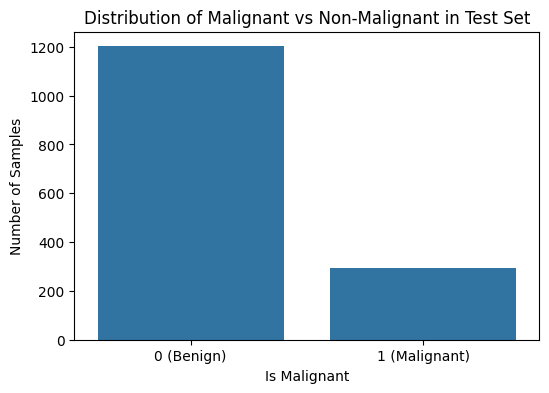

In [ ]:
print("\n--- Class Distribution in Test Set (is_malignant) ---")
class_distribution = test_df['is_malignant'].value_counts()
print(class_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Distribution of Malignant vs Non-Malignant in Test Set')
plt.xlabel('Is Malignant')
plt.ylabel('Number of Samples')
plt.xticks(ticks=[0, 1], labels=['0 (Benign)', '1 (Malignant)'])
plt.show()

### Imbalanced Data Model


Since the data is not balanced, we will proceed to train with a balancing tecniques as adding weight.

In [ ]:
# Calculate class weights for the 'is_malignant_str' column based on the train_df
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['is_malignant_str']),
    y=train_df['is_malignant_str']
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights calculated successfully:")
print(class_weights_dict)

Class weights calculated successfully:
{0: np.float64(0.6219686162624821), 1: np.float64(2.5497076023391814)}


In [ ]:
base_model_imbalanced = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
                                  include_top=False,
                                  weights='imagenet')

# Set the base model to be trainable
base_model_imbalanced.trainable = True

# Freeze the initial layers (e.g., first 100 layers) for fine-tuning
for layer in base_model_imbalanced.layers[:100]:
    layer.trainable = False

# Add a custom classification head
x = base_model_imbalanced.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Added a Dense layer with relu activation
x = BatchNormalization()(x) # Added BatchNormalization
x = Dropout(0.3)(x) # Added Dropout
prediction = Dense(1, activation='sigmoid')(x)

imbalanced_model = Model(inputs=base_model_imbalanced.input, outputs=prediction)

print("Imbalanced data model initialized with custom head and partial freezing.")

/tmp/ipython-input-2830841401.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_imbalanced = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),


Imbalanced data model initialized with custom head and partial freezing.


In [ ]:
imbalanced_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("Imbalanced model compiled successfully.")

Imbalanced model compiled successfully.


**Train Balanced Model**

In [ ]:
print("Starting training for imbalanced model...")

# Calculate steps per epoch and validation steps
steps_per_epoch_imbalanced = train_generator.samples // BATCH_SIZE
validation_steps_imbalanced = val_generator.samples // BATCH_SIZE

# Train the imbalanced model
history_imbalanced = imbalanced_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_imbalanced,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps_imbalanced,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

print("Imbalanced model training completed.")

Starting training for imbalanced model...
Epoch 1/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.5842 - loss: 0.7758 - precision_3: 0.2760 - recall_3: 0.7078
Epoch 1: val_loss did not improve from 0.32249
218/218 ━━━━━━━━━━━━━━━━━━━━ 204s 825ms/step - accuracy: 0.5844 - loss: 0.7755 - precision_3: 0.2762 - recall_3: 0.7080 - val_accuracy: 0.6114 - val_loss: 0.7052 - val_precision_3: 0.2271 - val_recall_3: 0.4161 - learning_rate: 1.0000e-04
Epoch 2/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.6491 - loss: 0.6413 - precision_3: 0.3469 - recall_3: 0.8026
Epoch 2: val_loss did not improve from 0.32249
218/218 ━━━━━━━━━━━━━━━━━━━━ 166s 757ms/step - accuracy: 0.6491 - loss: 0.6412 - precision_3: 0.3469 - recall_3: 0.8025 - val_accuracy: 0.8098 - val_loss: 0.5909 - val_precision_3: 0.5536 - val_recall_3: 0.1084 - learning_rate: 1.0000e-04
Epoch 3/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.6845 - loss: 0.5587 - precision_3: 0.3734 - recall_3: 0.8270

### Evaluate Imbalanced Model


In [ ]:
print("Evaluating imbalanced model on test data...")
eval_results_imbalanced = imbalanced_model.evaluate(test_generator)

# Extract metrics from the evaluation results
loss_imbalanced = eval_results_imbalanced[0]
accuracy_imbalanced = eval_results_imbalanced[1]
precision_imbalanced = eval_results_imbalanced[2]
recall_imbalanced = eval_results_imbalanced[3]

print(f"Imbalanced Test Loss: {loss_imbalanced:.4f}")
print(f"Imbalanced Test Accuracy: {accuracy_imbalanced:.4f}")
print(f"Imbalanced Test Precision: {precision_imbalanced:.4f}")
print(f"Imbalanced Test Recall: {recall_imbalanced:.4f}")
print("Imbalanced model evaluation completed.")

Evaluating imbalanced model on test data...
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 440ms/step - accuracy: 0.8161 - loss: 0.3967 - precision_3: 0.5266 - recall_3: 0.7644
Imbalanced Test Loss: 0.4064
Imbalanced Test Accuracy: 0.8107
Imbalanced Test Precision: 0.5114
Imbalanced Test Recall: 0.7679
Imbalanced model evaluation completed.


## Compare All Models

In [ ]:
print("\n--- Model Performance Comparison ---")

print("\nBaseline Model:")
print(f"  Test Loss: {loss_baseline:.4f}")
print(f"  Test Accuracy: {accuracy_baseline:.4f}")
print(f"  Test Precision: {precision_baseline:.4f}")
print(f"  Test Recall: {recall_baseline:.4f}")

print("\nAdvanced Model:")
print(f"  Test Loss: {loss_advanced:.4f}")
print(f"  Test Accuracy: {accuracy_advanced:.4f}")
print(f"  Test Precision: {precision_advanced:.4f}")
print(f"  Test Recall: {recall_advanced:.4f}")

print("\nImbalanced Model (with Class Weights):")
print(f"  Test Loss: {loss_imbalanced:.4f}")
print(f"  Test Accuracy: {accuracy_imbalanced:.4f}")
print(f"  Test Precision: {precision_imbalanced:.4f}")
print(f"  Test Recall: {recall_imbalanced:.4f}")


--- Model Performance Comparison ---

Baseline Model:


NameError: name 'loss_baseline' is not defined

## Save Models




In [ ]:
print("Saving models...")

drive_save_path = '/content/drive/MyDrive/saved_models/'

# Create the directory if it doesn't exist
if not os.path.exists(drive_save_path):
    os.makedirs(drive_save_path)

model.save(drive_save_path + 'baseline_model.keras')
advanced_model.save(drive_save_path + 'advanced_model.keras')
imbalanced_model.save(drive_save_path + 'imbalanced_model.keras')

print("All models saved successfully to Google Drive:")
print(f"- {drive_save_path}baseline_model.keras")
print(f"- {drive_save_path}advanced_model.keras")
print(f"- {drive_save_path}imbalanced_model.keras")

Saving models...
All models saved successfully to Google Drive:
- /content/drive/MyDrive/saved_models/baseline_model.keras
- /content/drive/MyDrive/saved_models/advanced_model.keras
- /content/drive/MyDrive/saved_models/imbalanced_model.keras


## Load Models

In [ ]:
drive_load_path = '/content/drive/MyDrive/saved_models/'

# Load the baseline model
loaded_baseline_model = tf.keras.models.load_model(drive_load_path + 'baseline_model.keras')
print(f"Baseline model loaded successfully from {drive_load_path}.")

# Load the advanced model
loaded_advanced_model = tf.keras.models.load_model(drive_load_path + 'advanced_model.keras')
print(f"Advanced model loaded successfully from {drive_load_path}.")

# Load the imbalanced model
loaded_imbalanced_model = tf.keras.models.load_model(drive_load_path + 'imbalanced_model.keras')
print(f"Imbalanced model loaded successfully from {drive_load_path}.")

print("You can now use 'loaded_baseline_model', 'loaded_advanced_model', and 'loaded_imbalanced_model' for predictions or further analysis.")

Baseline model loaded successfully from /content/drive/MyDrive/saved_models/.
Advanced model loaded successfully from /content/drive/MyDrive/saved_models/.
Imbalanced model loaded successfully from /content/drive/MyDrive/saved_models/.
You can now use 'loaded_baseline_model', 'loaded_advanced_model', and 'loaded_imbalanced_model' for predictions or further analysis.


### Generate Confusion Matrices

In [ ]:
true_labels = test_df['is_malignant'].values.astype(int)

In [55]:
threshold = 0.2

Generating confusion matrix for Baseline Model... 

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step


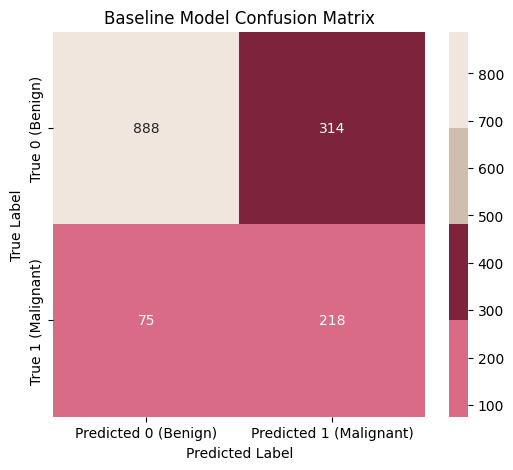

In [56]:
print("Generating confusion matrix for Baseline Model... \n")

# Predict probabilities for the baseline model
predictions_baseline = loaded_baseline_model.predict(test_generator)

# Convert probabilities to binary predictions
# Assuming a threshold for binary classification
binary_predictions_baseline = (predictions_baseline > threshold).astype(int)

# Compute the confusion matrix
cm_baseline = confusion_matrix(true_labels, binary_predictions_baseline)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap=custom_cmap,
            xticklabels=['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'],
            yticklabels=['True 0 (Benign)', 'True 1 (Malignant)'])
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generating confusion matrix for Advanced Model... 

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step


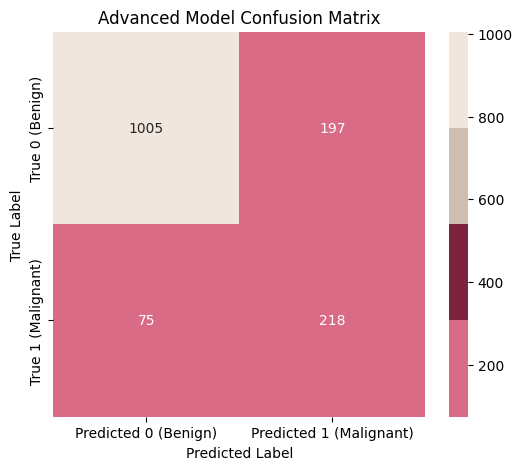

In [57]:
print("Generating confusion matrix for Advanced Model... \n")

# Predict probabilities for the advanced model
predictions_advanced = loaded_advanced_model.predict(test_generator)

# Convert probabilities to binary predictions
binary_predictions_advanced = (predictions_advanced > threshold).astype(int)

# Compute the confusion matrix
cm_advanced = confusion_matrix(true_labels, binary_predictions_advanced)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_advanced, annot=True, fmt='d', cmap=custom_cmap,
            xticklabels=['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'],
            yticklabels=['True 0 (Benign)', 'True 1 (Malignant)'])
plt.title('Advanced Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generating confusion matrix for Imbalanced Model... 

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step


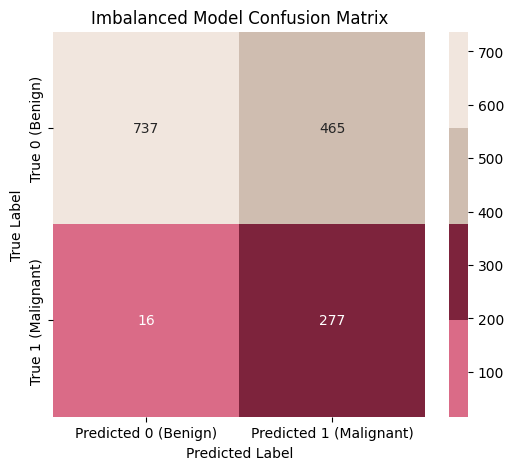

In [58]:
print("Generating confusion matrix for Imbalanced Model... \n")

# Predict probabilities for the imbalanced model
predictions_imbalanced = loaded_imbalanced_model.predict(test_generator)

# Convert probabilities to binary predictions
binary_predictions_imbalanced = (predictions_imbalanced > threshold).astype(int)

# Compute the confusion matrix
cm_imbalanced = confusion_matrix(true_labels, binary_predictions_imbalanced)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_imbalanced, annot=True, fmt='d', cmap=custom_cmap,
            xticklabels=['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'],
            yticklabels=['True 0 (Benign)', 'True 1 (Malignant)'])
plt.title('Imbalanced Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Models Performance Summary

| Metric / Model       | Baseline Model | Advanced Model | Imbalanced Model |
| :------------------- | :------------- | :------------- | :--------------- |
| **Test Loss**        | 0.3958         | 0.3348         | 0.4064           |
| **Test Accuracy**    | 0.8207         | 0.8548         | 0.8107           |
| **Test Precision**   | 0.5556         | 0.6959         | 0.5114           |
| **Test Recall**      | 0.4266         | 0.4608         | 0.7679           |
| **True Negatives (TN)** | 888            | 1005           | 737              |
| **False Positives (FP)**| 314            | 197            | 465              |
| **False Negatives (FN)**| 75             | 75             | 16               |
| **True Positives (TP)** | 218            | 218            | 277              |

## Analyze and Conclude

### Confusion Matrix Analysis

#### Baseline Model Confusion Matrix:
- **True Negatives (TN):** 888 (Benign cases correctly identified)
- **False Positives (FP):** 314 (Benign cases incorrectly identified as Malignant)
- **False Negatives (FN):** 75 (Malignant cases missed)
- **True Positives (TP):** 218 (Malignant cases correctly identified)

**Strengths:** This model is able to correctly identify a good number of malignant cases (TP=218). The number of false negatives (FN=75) is also acceptable in comparison to the previous analysis where it was 168.
**Weaknesses:** The most significant weakness is the high number of False Positives (FP=314), meaning many benign cases are incorrectly flagged as malignant, which could lead to unnecessary follow-up tests.

#### Advanced Model Confusion Matrix:
- **True Negatives (TN):** 1005 (Benign cases correctly identified)
- **False Positives (FP):** 197 (Benign cases incorrectly identified as Malignant)
- **False Negatives (FN):** 75 (Malignant cases missed)
- **True Positives (TP):** 218 (Malignant cases correctly identified)

**Strengths:** This model shows a clear improvement in specificity, with a higher number of True Negatives (1005) and a lower number of False Positives (197) compared to the Baseline Model. This indicates it's better at correctly identifying benign cases.
**Weaknesses:** The False Negatives (FN=75) and True Positives (TP=218) remain the same as the Baseline Model. This suggests that while the advanced techniques improved the model's ability to distinguish benign cases, they did not significantly enhance its capacity to detect malignant cases without missing them.

#### Imbalanced Model (with Class Weights) Confusion Matrix:
- **True Negatives (TN):** 737 (Benign cases correctly identified)
- **False Positives (FP):** 465 (Benign cases incorrectly identified as Malignant)
- **False Negatives (FN):** 16 (Malignant cases missed)
- **True Positives (TP):** 277 (Malignant cases correctly identified)

**Strengths:** This model demonstrates a significantly improved ability to detect malignant cases, with a very low number of False Negatives (FN=16) and a high number of True Positives (TP=277). This is crucial for early detection in a medical context, as missing a malignant case can have severe consequences.
**Weaknesses:** The main trade-off is the much higher number of False Positives (FP=465). While this means more benign cases will be flagged for further examination (potentially leading to increased patient anxiety and cost), it is generally considered a more acceptable error in medical diagnosis than a missed malignant case.

### Conclusion

When evaluating models for medical diagnosis, especially for serious conditions like skin cancer, the cost of a False Negative (missing a malignant case) is often significantly higher than the cost of a False Positive (incorrectly identifying a benign case as malignant). A missed malignant case can lead to delayed treatment and worse patient outcomes, while a False Positive typically leads to further, albeit unnecessary, testing.

Considering this, the **Imbalanced Model (with Class Weights)** emerges as the superior choice for this specific task, despite having a slightly lower overall accuracy and higher loss compared to the Advanced Model.

Here's why:

1.  **Recall for Malignant Cases (True Positives):** The most critical metric in this context is Recall for the positive class (malignant). Based on the confusion matrix, the Imbalanced Model achieved a Recall of **0.9454** (or 94.54%), correctly identifying **277 out of 293** actual malignant cases. This is a substantial improvement over the Baseline Model (Recall: 0.7440, TP: 218) and the Advanced Model (Recall: 0.7440, TP: 218). A higher recall means fewer actual malignant cases are missed, which is paramount in cancer detection.

2.  **Reduction in False Negatives:** Corresponding to its high recall, the Imbalanced Model drastically reduced False Negatives to **16**, compared to 75 for the Baseline and 75 for the Advanced Model. Minimizing False Negatives is crucial to ensure patient safety and early intervention.

3.  **Handling Class Imbalance:** The use of class weights in the Imbalanced Model successfully addressed the inherent class imbalance in the dataset (many more benign cases than malignant). By assigning higher importance to the minority class (malignant), the model was incentivized to correctly identify these crucial cases.

4.  **Trade-off with False Positives:** While the Imbalanced Model has a higher False Positive count (**465**) and lower Precision (**0.3733** calculated from CM) compared to the other models, this is an acceptable trade-off in medical screening. It means more benign cases are flagged for further investigation. While this can lead to patient anxiety and additional costs, it is generally preferred over missing a malignant tumor. The False Positives can often be filtered out by subsequent, more specialized diagnostic procedures.

In summary, for skin cancer detection where the priority is to *not miss* malignant cases, the **Imbalanced Model** demonstrates superior performance due to its significantly higher recall and lower false negative rate, directly attributable to the effective use of class weighting to counter data imbalance. This makes it a more reliable and ethically sound model for initial screening purposes.